In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

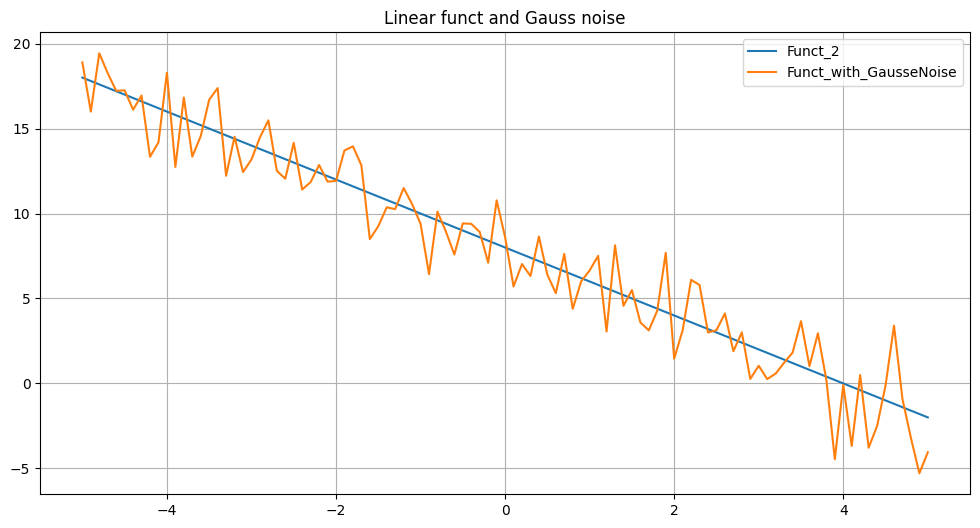

In [4]:
x_values_f2, y_values_f2 = [], []
x_values_noise, y_values_noise = [], []

with open('/home/angst/DataAnalysis/lab3/files/Funct_with_GausseNoise.txt', 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        x_values_noise.append(x)
        y_values_noise.append(y)


with open('/home/angst/DataAnalysis/lab3/files/Funct_2.txt', 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        x_values_f2.append(x)
        y_values_f2.append(y)


plt.figure(figsize=(12, 6))
plt.plot(x_values_f2, y_values_f2, label='Funct_2')
plt.plot(x_values_noise, y_values_noise, label='Funct_with_GausseNoise')
plt.title('Linear funct and Gauss noise')
plt.grid()
plt.legend()
plt.show()

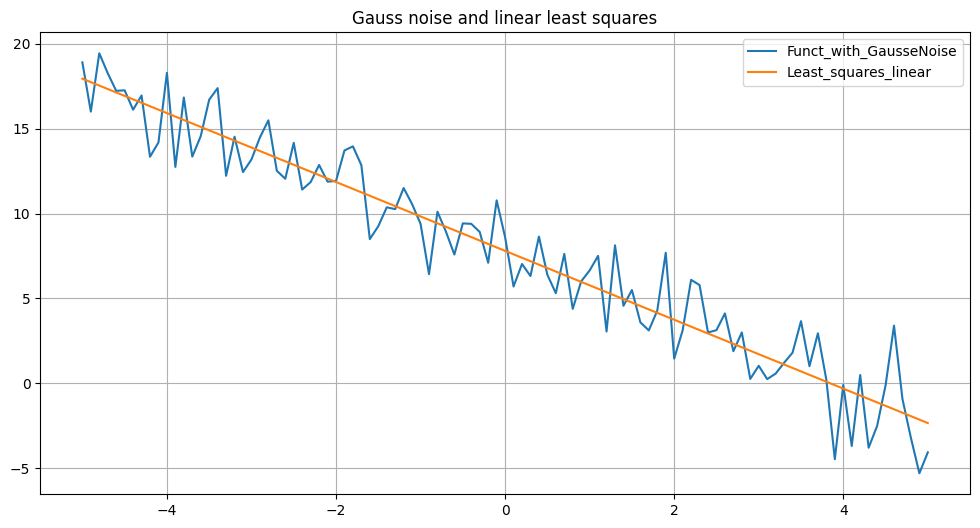

In [5]:
x_least_squares_linear = []
y_least_squares_linear = []

with open('/home/angst/DataAnalysis/lab3/files/Least_squares_linear.txt', 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        x_least_squares_linear.append(x)
        y_least_squares_linear.append(y)


plt.figure(figsize=(12, 6))
plt.plot(x_values_noise, y_values_noise, label='Funct_with_GausseNoise')
plt.plot(x_least_squares_linear, y_least_squares_linear, label='Least_squares_linear')
plt.title('Gauss noise and linear least squares')
plt.grid()
plt.legend()
plt.show()


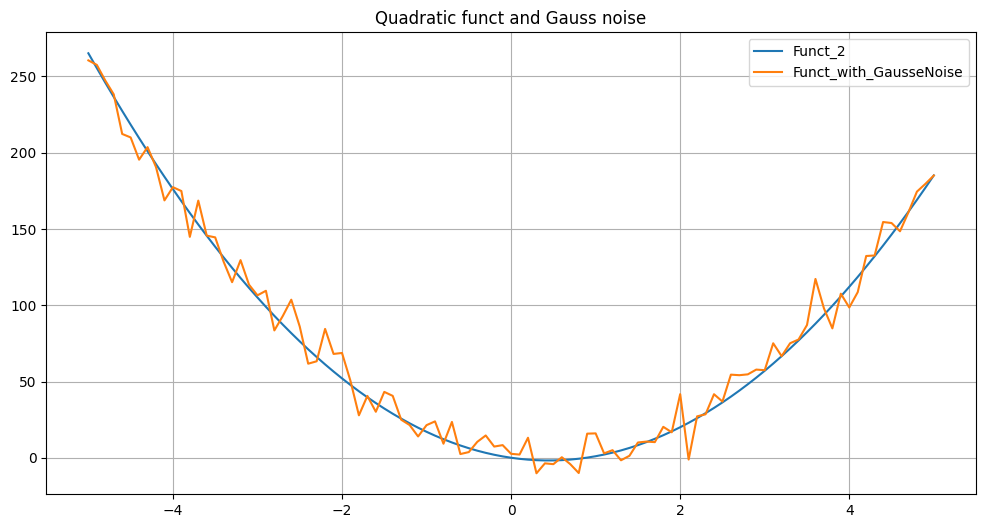

In [6]:
x_values_f2, y_values_f2 = [], []  # Changed variable names to match usage
x_values_noise, y_values_noise = [], []

with open('/home/angst/DataAnalysis/lab3/files/Funct_quadratic_with_GausseNoise.txt', 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        x_values_noise.append(x)
        y_values_noise.append(y)

with open('/home/angst/DataAnalysis/lab3/files/Funct_2_quadratic.txt', 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        x_values_f2.append(x)
        y_values_f2.append(y)

plt.figure(figsize=(12, 6))
plt.plot(x_values_f2, y_values_f2, label='Funct_2')
plt.plot(x_values_noise, y_values_noise, label='Funct_with_GausseNoise')
plt.title('Quadratic funct and Gauss noise')
plt.grid()
plt.legend()
plt.show()

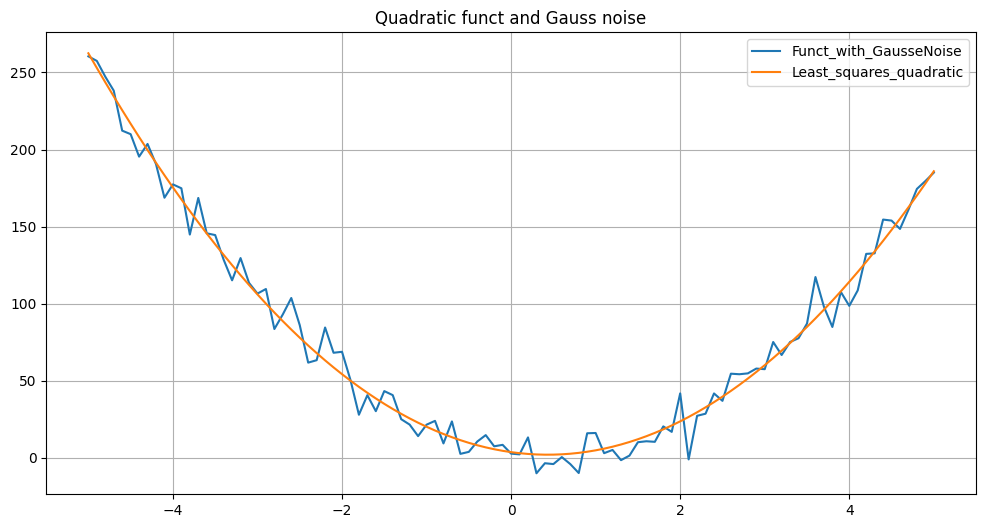

In [7]:
x_values_f2, y_values_f2 = [], []
x_values_noise, y_values_noise = [], []

with open('/home/angst/DataAnalysis/lab3/files/Funct_quadratic_with_GausseNoise.txt', 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        x_values_noise.append(x)
        y_values_noise.append(y)

with open('/home/angst/DataAnalysis/lab3/files/Least_squares_quadratic.txt', 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        x_values_f2.append(x)
        y_values_f2.append(y)

plt.figure(figsize=(12, 6))
plt.plot(x_values_noise, y_values_noise, label='Funct_with_GausseNoise')
plt.plot(x_values_f2, y_values_f2, label='Least_squares_quadratic')
plt.title('Quadratic funct and Gauss noise')
plt.grid()
plt.legend()
plt.show()

/tmp/ipykernel_9418/669472097.py:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x_orig, y_orig, 'k-', label='Original function', linewidth=2, color='green')


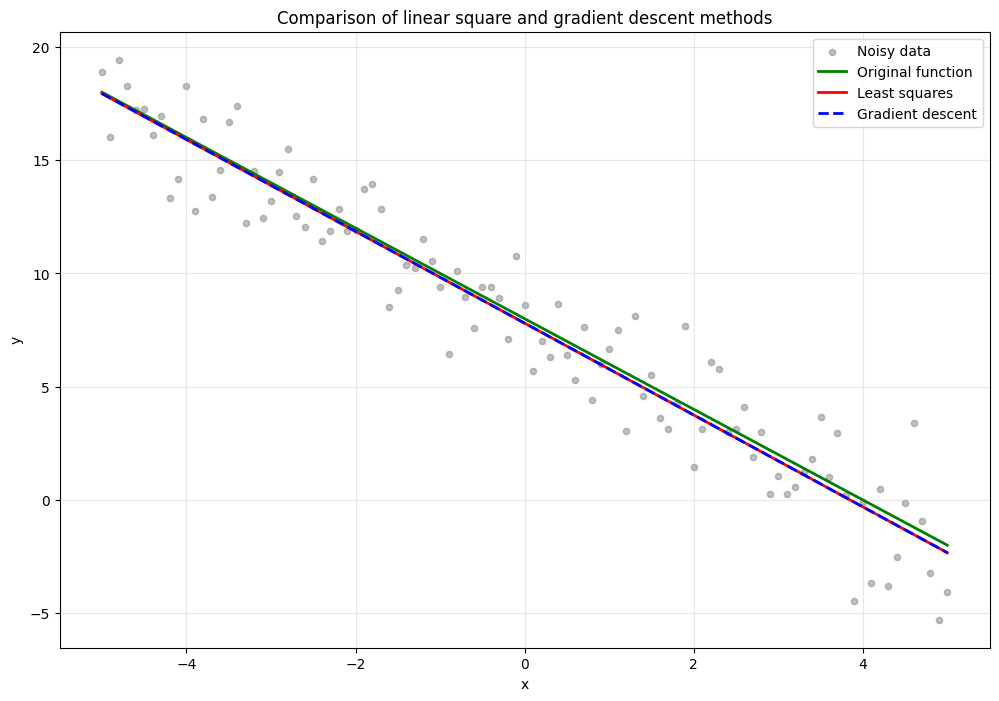

In [8]:
def load_data(filename):
    x, y = [], []
    with open(filename, 'r') as f:
        for line in f:
            values = line.strip().split()
            if len(values) == 2:
                x.append(float(values[0]))
                y.append(float(values[1]))
    return np.array(x), np.array(y)

x_noise, y_noise = load_data('files/Funct_with_GausseNoise.txt')
x_ls, y_ls = load_data('files/Least_squares_linear.txt')
x_grad, y_grad = load_data('files/Least_squares_gradient.txt')
x_orig, y_orig = load_data('files/Funct_2.txt')

plt.figure(figsize=(12, 8))

plt.scatter(x_noise, y_noise, color='gray', alpha=0.5, label='Noisy data', s=20)
plt.plot(x_orig, y_orig, 'k-', label='Original function', linewidth=2, color='green')
plt.plot(x_ls, y_ls, 'r-', label='Least squares', linewidth=2)
plt.plot(x_grad, y_grad, 'b--', label='Gradient descent', linewidth=2)

plt.title('Comparison of linear square and gradient descent methods')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

<Figure size 1200x800 with 0 Axes>

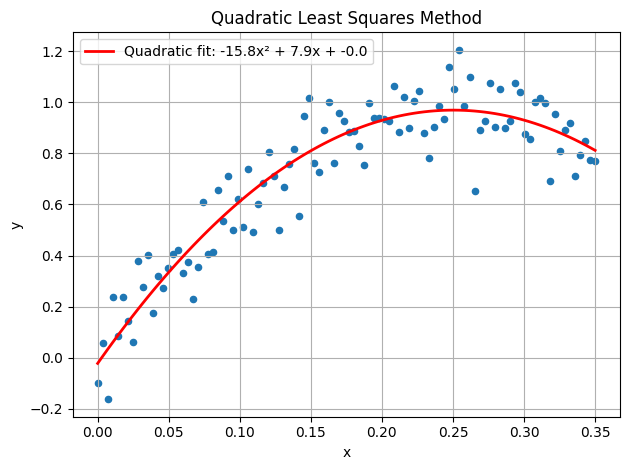

In [17]:
df = pd.read_excel('МНК_6.xlsx')

x = df['x']
y_noisy = df['y_noisy']

df = pd.DataFrame({
    'x': x,
    'y': y_noisy
})
plt.figure(figsize=(12, 8))

coefficients = np.polyfit(df['x'], df['y'], 2)
x_ls = np.linspace(df['x'].min(), df['x'].max(), 100)
y_ls = coefficients[0] * x_ls**2 + coefficients[1] * x_ls + coefficients[2]

df.plot(x='x', y='y', kind='scatter', title='Quadratic Least Squares Method')
plt.plot(x_ls, y_ls, 'r-', 
         label=f'Quadratic fit: {coefficients[0]:.1f}x² + {coefficients[1]:.1f}x + {coefficients[2]:.1f}', 
         linewidth=2)
plt.grid(True)
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()